LaTeX has been enabled for text rendering.
        RELATÓRIO ESTATÍSTICO DO SISTEMA PETC DUAL-CHANNEL        
 Período de Amostragem (h)       : 0.0500 s
 Amostras Discretas (s_m)        : 601
 Transmissões Canal SC (Sensor)  : 81
 Redução de Tráfego Canal SC     : 86.52%
 Transmissões Canal CA (Atuador) : 587
 Redução de Tráfego Canal CA     : 2.33%
--------------------------------------------------------------
 Norma do Erro ||e[s_m]||: RMS = 0.196661 | Máx Abs = 1.574489


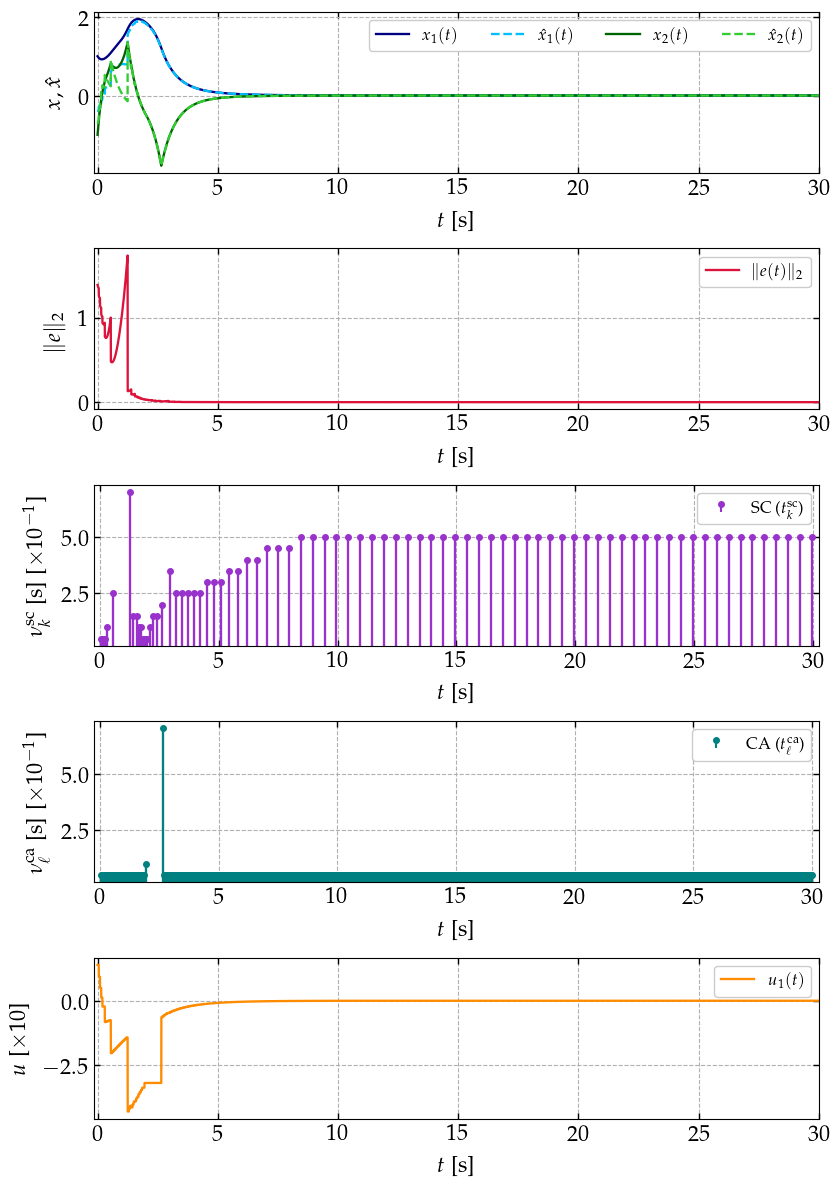

In [17]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from Utils import Graphs, Notebook

Notebook.setup()


def load_signal(filepath: str) -> np.ndarray:
  return np.fromfile(filepath, dtype='float64')


dir_path = 'simulations/lit-system-dual-channel-setm'

# -------------------------------------------------------------
# 1. CARREGAMENTO DOS DADOS DA SIMULAÇÃO DUAL-CHANNEL
# -------------------------------------------------------------
h = 5e-2  # Período de amostragem fundamental

time = load_signal(f'{dir_path}/time.bin')
sc_trigger_times = load_signal(f'{dir_path}/sc_trigger_times.bin')
ca_trigger_times = load_signal(f'{dir_path}/ca_trigger_times.bin')

x1 = load_signal(f'{dir_path}/x1.bin')
x2 = load_signal(f'{dir_path}/x2.bin')
x_est1 = load_signal(f'{dir_path}/x_est1.bin')
x_est2 = load_signal(f'{dir_path}/x_est2.bin')
e1 = load_signal(f'{dir_path}/e1.bin')
e2 = load_signal(f'{dir_path}/e2.bin')
u1 = load_signal(f'{dir_path}/u1.bin')

# -------------------------------------------------------------
# 2. PROCESSAMENTO ESTATÍSTICO E AMOSTRAGEM DISCRETA
# -------------------------------------------------------------
dt = time[1] - time[0]
step_ratio = int(np.round(h / dt))

sample_indices = np.arange(0, len(time), step_ratio)
s_m_times = time[sample_indices]

error_norm = np.sqrt(e1**2 + e2**2)
error_norm_sm = error_norm[sample_indices]

# Tratamento para o canal SC (Sensor-Controlador)
sc_inter_event_times = np.zeros_like(sc_trigger_times)
if len(sc_trigger_times) > 1:
  sc_inter_event_times[1:] = np.diff(sc_trigger_times)
sc_iet_valid = (
    sc_inter_event_times[1:]
    if len(sc_inter_event_times) > 1
    else np.array([0.0])
)
sc_trigger_valid = (
    sc_trigger_times[1:] if len(sc_trigger_times) > 1 else np.array([0.0])
)

sc_iet_mean = float(np.mean(sc_iet_valid))
sc_transmissions = len(sc_trigger_times)

# Tratamento para o canal CA (Controlador-Atuador)
ca_inter_event_times = np.zeros_like(ca_trigger_times)
if len(ca_trigger_times) > 1:
  ca_inter_event_times[1:] = np.diff(ca_trigger_times)
ca_iet_valid = (
    ca_inter_event_times[1:]
    if len(ca_inter_event_times) > 1
    else np.array([0.0])
)
ca_trigger_valid = (
    ca_trigger_times[1:] if len(ca_trigger_times) > 1 else np.array([0.0])
)

ca_iet_mean = float(np.mean(ca_iet_valid))
ca_transmissions = len(ca_trigger_times)

total_samples_sm = len(s_m_times)
sc_reduction_pct = (1.0 - (sc_transmissions / total_samples_sm)) * 100.0
ca_reduction_pct = (1.0 - (ca_transmissions / total_samples_sm)) * 100.0

norm_rms = float(np.sqrt(np.mean(error_norm_sm**2)))
norm_max = float(np.max(np.abs(error_norm_sm)))

plot_style = Graphs.PlotStyle()
plot_style.legend_ncol = 4

print('=' * 62)
print('        RELATÓRIO ESTATÍSTICO DO SISTEMA PETC DUAL-CHANNEL        ')
print('=' * 62)
print(f' Período de Amostragem (h)       : {h:.4f} s')
print(f' Amostras Discretas (s_m)        : {total_samples_sm}')
print(f' Transmissões Canal SC (Sensor)  : {sc_transmissions}')
print(f' Redução de Tráfego Canal SC     : {sc_reduction_pct:.2f}%')
print(f' Transmissões Canal CA (Atuador) : {ca_transmissions}')
print(f' Redução de Tráfego Canal CA     : {ca_reduction_pct:.2f}%')
print('-' * 62)
print(
    f' Norma do Erro ||e[s_m]||: RMS = {norm_rms:.6f} | Máx Abs = {norm_max:.6f}'
)
print('=' * 62)

# -------------------------------------------------------------
# 3. PLOTAGEM VIA UTILITÁRIO GPH (SUBPLOT MOSAIC)
# -------------------------------------------------------------
fig, axs = plt.subplot_mosaic(
    [['x'], ['e'], ['iet_sc'], ['iet_ca'], ['u']], figsize=(8.5, 12)
)

# 1. Estados Reais vs. Estimados
_ = Graphs.plot(
    axs['x'],
    time,
    [x1, x_est1, x2, x_est2],
    label=[r'$x_1(t)$', r'$\hat{x}_1(t)$', r'$x_2(t)$', r'$\hat{x}_2(t)$'],
    xlabel='$t$',
    x_unit='s',
    x_use_prefixes=True,
    ylabel=r'$x, \hat{x}$',
    color=['navy', 'deepskyblue', 'darkgreen', 'limegreen'],
    linestyle=['-', '--', '-', '--'],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
    style=plot_style,
)

# 2. Norma Contínua do Erro de Estimação
_ = Graphs.plot(
    axs['e'],
    time,
    [error_norm],
    label=[r'$\|e(t)\|_2$'],
    xlabel='$t$',
    x_unit='s',
    x_use_prefixes=True,
    ylabel=r'$\|e\|_2$',
    color=['crimson'],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
)

# 3. Intervalos Inter-Eventos - Canal SC (Stem)
_ = Graphs.stem(
    axs['iet_sc'],
    sc_trigger_valid,
    sc_iet_valid,
    label=[r'SC ($t_k^{\mathrm{sc}}$)'],
    xlabel='$t$',
    x_unit='s',
    x_use_prefixes=True,
    ylabel=r'$\nu_k^{\mathrm{sc}}$ [s]',
    color=['darkorchid'],
    x_pad=(0.01, 0.01),
    y_pad=(0.05, 0.05),
)

# 4. Intervalos Inter-Eventos - Canal CA (Stem)
_ = Graphs.stem(
    axs['iet_ca'],
    ca_trigger_valid,
    ca_iet_valid,
    label=[r'CA ($t_\ell^{\mathrm{ca}}$)'],
    xlabel='$t$',
    x_unit='s',
    x_use_prefixes=True,
    ylabel=r'$\nu_\ell^{\mathrm{ca}}$ [s]',
    color=['teal'],
    x_pad=(0.01, 0.01),
    y_pad=(0.05, 0.05),
)

# 5. Sinal de Controle em Malha Fechada (ZOH)
_ = Graphs.plot(
    axs['u'],
    time,
    [u1],
    label=[r'$u_1(t)$'],
    xlabel='$t$',
    x_unit='s',
    x_use_prefixes=True,
    ylabel=r'$u$',
    color=['darkorange'],
    x_pad=(0.005, 0.0),
    y_pad=(0.05, 0.05),
)

plt.tight_layout()
plt.show()

### Comparação analítica da dinâmica do erro de estimação

     VALIDAÇÃO ANALÍTICA DA DINÂMICA DO OBSERVADOR IMPULSIVO  
 Máximo Desvio Absoluto (Simulação vs. Analítico): 4.85e-01
 Resíduo RMS Global                              : 1.15e-02


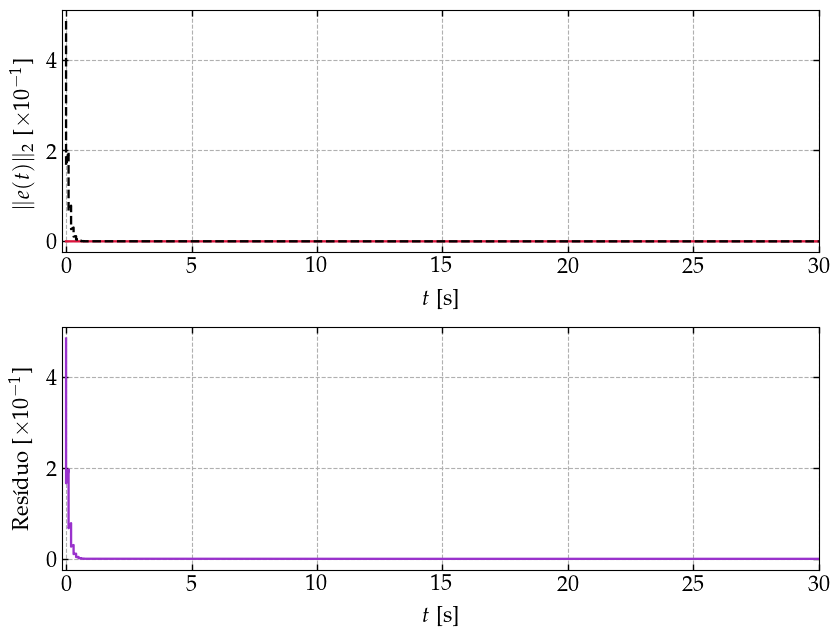

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Supondo a importação: import graph_lib as gph


def load_signal(filepath: str) -> np.ndarray:
  return np.fromfile(filepath, dtype='float64')


dir_path = 'simulations/lit-system-closed-loop-setm-event-map'

# -------------------------------------------------------------
# 1. CARREGAMENTO DOS DADOS DA SIMULAÇÃO (C++)
# -------------------------------------------------------------
time = load_signal(f'{dir_path}/time.bin')
trigger_times = load_signal(f'{dir_path}/trigger_times.bin')
e1_sim = load_signal(f'{dir_path}/e1.bin')
e2_sim = load_signal(f'{dir_path}/e2.bin')

e_sim = np.vstack([e1_sim, e2_sim])  # Dimensão: (nx, num_steps)
norm_e_sim = np.sqrt(np.sum(e_sim**2, axis=0))

# -------------------------------------------------------------
# 2. PARÂMETROS DO MODELO DA PLANTA E DO OBSERVADOR
# -------------------------------------------------------------
# Defina aqui as matrizes A, L, C e as condições iniciais nominais
A = np.array([
    [0.0, 1.0],
    [-4.0, 0.4]
], dtype=np.float64)

C = np.array([[1.0, 0.0],
              [0.0, 1.0]], dtype=np.float64)  # Ou C = I

# Ganho L recuperado da síntese LMI
L = np.array([
    [6.55e-1, -7.46e-4],
    [-1.42e-3, 6.57e-1]
], dtype=np.float64)

x0 = np.array([1.0, -1.0], dtype=np.float64)
x_est0 = np.array([0.0, 0.0], dtype=np.float64)
e0_minus = x0 - x_est0


def get_alpha(t: float) -> np.ndarray:
  return np.zeros(C.shape[0], dtype=np.float64)


# -------------------------------------------------------------
# 3. PROPAGAÇÃO ANALÍTICA PURA DO ERRO (FLUXO + SALTO)
# -------------------------------------------------------------
num_steps = len(time)
nx = A.shape[0]
e_analytical = np.zeros((nx, num_steps), dtype=np.float64)

# Mapeamento dos índices dos eventos na grade de tempo
trig_indices = np.searchsorted(time, trigger_times)
trig_indices = np.clip(trig_indices, 0, num_steps - 1)

# A. Condição inicial pós-primeiro salto em t0 = 0
e_current_plus = (np.eye(nx) - L @ C) @ e0_minus - L @ get_alpha(time[0])

# B. Integração analítica intervalo a intervalo
for k in range(len(trig_indices)):
  idx_start = trig_indices[k]
  idx_end = trig_indices[k + 1] if (k + 1 < len(trig_indices)) else num_steps

  t_start = time[idx_start]

  # Propagação contínua exata: e(t) = expm(A * (t - t_k)) @ e(t_k^+)
  for i in range(idx_start, idx_end):
    dt_k = time[i] - t_start
    e_analytical[:, i] = expm(A * dt_k) @ e_current_plus

  # Aplicação do salto no final do intervalo (instante do próximo evento)
  if k + 1 < len(trig_indices):
    t_next = time[idx_end]
    e_minus_next = expm(A * (t_next - t_start)) @ e_current_plus
    e_current_plus = (np.eye(nx) - L @ C) @ e_minus_next - \
        L @ get_alpha(t_next)

norm_e_analytical = np.sqrt(np.sum(e_analytical**2, axis=0))

# -------------------------------------------------------------
# 4. AVALIAÇÃO DE CONFORMIDADE E RESÍDUO NUMÉRICO
# -------------------------------------------------------------
residual = np.abs(norm_e_sim - norm_e_analytical)
max_residual = np.max(residual)
rms_residual = np.sqrt(np.mean(residual**2))

print("=" * 60)
print("     VALIDAÇÃO ANALÍTICA DA DINÂMICA DO OBSERVADOR IMPULSIVO  ")
print("=" * 60)
print(f" Máximo Desvio Absoluto (Simulação vs. Analítico): {max_residual:.2e}")
print(f" Resíduo RMS Global                              : {rms_residual:.2e}")
print("=" * 60)

# -------------------------------------------------------------
# 5. PLOTAGEM COMPARATIVA (VIA GPH)
# -------------------------------------------------------------
fig, axs = plt.subplot_mosaic([['compare'], ['diff']], figsize=(8.5, 6.5))

# 1. Comparação Direta das Normas
_ = Graphs.plot(
    axs['compare'], time, [norm_e_sim, norm_e_analytical],
    # label=[r'$\|e(t)\|_{\text{Simulado (RK5)}}$',
    #  r'$\|e(t)\|_{\text{Analítico}}$'],
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=r'$\|e(t)\|_2$',
    color=['crimson', 'black'],
    linestyle=['-', '--'],
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

# 2. Resíduo de Integração Numérica |Sim - Analítico|
_ = Graphs.plot(
    axs['diff'], time, [residual],
    # label=[r'Erro de Truncamento $|\|e_{\text{sim}}\| - \|e_{\text{ana}}\||$'],
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel='Resíduo',
    color=['darkorchid'],
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

plt.tight_layout()
plt.show()

                 RELATÓRIO ESTATÍSTICO PETC               
 Transmissões ETM              : 54
 Intervalos Inter-Eventos      : Média = 0.2830s | Min = 0.1000s | Max = 0.4000s


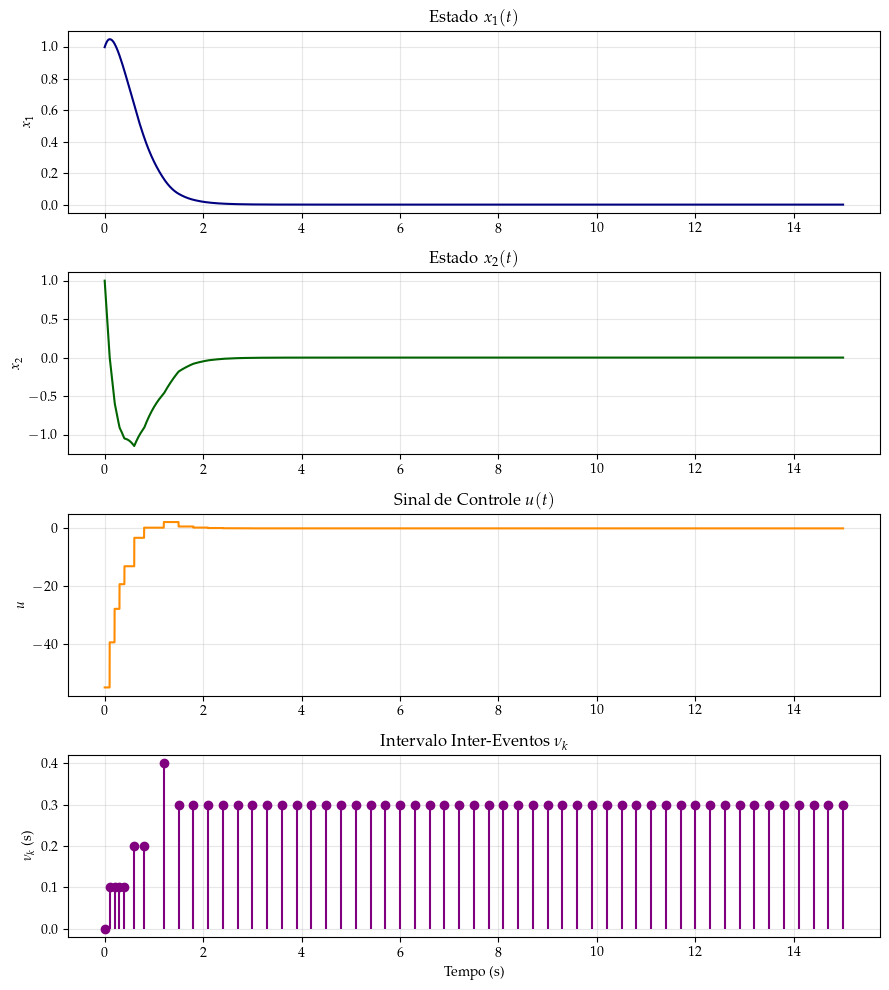

In [5]:
import matplotlib.pyplot as plt
import numpy as np


def load_signal(filepath):
  return np.fromfile(filepath, dtype='float64')


dir_path = 'simulations/lit-system-closed-loop-setm'

# -------------------------------------------------------------
# 1. LOAD SIGNALS
# -------------------------------------------------------------
time = load_signal(f'{dir_path}/time.bin')
trigger_times = load_signal(f'{dir_path}/trigger_times.bin')

x1 = load_signal(f'{dir_path}/x1.bin')
x2 = load_signal(f'{dir_path}/x2.bin')
u1 = load_signal(f'{dir_path}/u1.bin')


# -------------------------------------------------------------
# 2. INTER-EVENT TIMES
# -------------------------------------------------------------
inter_event_times = np.zeros_like(trigger_times)

if len(trigger_times) > 1:
  inter_event_times[1:] = np.diff(trigger_times)


# -------------------------------------------------------------
# 3. STATISTICS
# -------------------------------------------------------------
iet = inter_event_times[1:] if len(inter_event_times) > 1 else np.array([])

iet_mean = np.mean(iet) if len(iet) > 0 else 0.0
iet_min = np.min(iet) if len(iet) > 0 else 0.0
iet_max = np.max(iet) if len(iet) > 0 else 0.0

total_transmissions = len(trigger_times)

print("==========================================================")
print("                 RELATÓRIO ESTATÍSTICO PETC               ")
print("==========================================================")
print(f" Transmissões ETM              : {total_transmissions}")
print(
    f" Intervalos Inter-Eventos      : "
    f"Média = {iet_mean:.4f}s | "
    f"Min = {iet_min:.4f}s | "
    f"Max = {iet_max:.4f}s"
)
print("==========================================================")


# =============================================================
# 4. PLOTAGEM
# =============================================================
fig, (ax1, ax2, ax3, ax4) = plt.subplots(
    4, 1,
    figsize=(9, 10),
    sharex=False
)


# -------------------------------------------------------------
# Estado x1
# -------------------------------------------------------------
ax1.plot(
    time,
    x1,
    color='navy',
    linewidth=1.5
)

ax1.set_title(r'Estado $x_1(t)$')
ax1.set_ylabel(r'$x_1$')
ax1.grid(True, alpha=0.3)


# -------------------------------------------------------------
# Estado x2
# -------------------------------------------------------------
ax2.plot(
    time,
    x2,
    color='darkgreen',
    linewidth=1.5
)

ax2.set_title(r'Estado $x_2(t)$')
ax2.set_ylabel(r'$x_2$')
ax2.grid(True, alpha=0.3)


# -------------------------------------------------------------
# Sinal de controle
# -------------------------------------------------------------
ax3.plot(
    time,
    u1,
    color='darkorange',
    linewidth=1.5
)

ax3.set_title(r'Sinal de Controle $u(t)$')
ax3.set_ylabel(r'$u$')
ax3.grid(True, alpha=0.3)


# -------------------------------------------------------------
# Intervalo entre eventos
# -------------------------------------------------------------
ax4.stem(
    trigger_times,
    inter_event_times,
    linefmt='purple',
    markerfmt='o',
    basefmt=' '
)

ax4.set_title(r'Intervalo Inter-Eventos $\nu_k$')
ax4.set_xlabel('Tempo (s)')
ax4.set_ylabel(r'$\nu_k$ (s)')
ax4.grid(True, alpha=0.3)


fig.tight_layout()
plt.show()